In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [3]:
file_path = '/content/drive/MyDrive/FYP/Datasets/machine_learning_balance_UNSW_NB15_data.csv'
df = pd.read_csv(file_path)
print(df)

             dur  spkts  dpkts         sload         dload  smeansz  dmeansz  \
0       0.000009      2      0  5.066666e+07  0.000000e+00       57        0   
1       0.000008      2      0  5.700000e+07  0.000000e+00       57        0   
2       0.025125      8     10  2.887960e+05  2.362587e+05      130       82   
3       0.051998     48     50  4.481711e+05  4.601100e+06       62      610   
4       0.000009      2      0  5.066666e+07  0.000000e+00       57        0   
...          ...    ...    ...           ...           ...      ...      ...   
642561  0.004613      4      4  7.387817e+05  4.058097e+05      142       78   
642562  0.015910     46     48  1.403897e+06  1.543734e+07       62      653   
642563  0.000008      2      0  5.700000e+07  0.000000e+00       57        0   
642564  0.000008      2      0  1.320000e+08  0.000000e+00      132        0   
642565  1.401753    102    100  8.259944e+04  9.681021e+04      143      171   

          sintpkt    dintpkt    synack 

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
X = df.drop('label', axis=1)
y = df['label']

# Handle NaN and infinite values
X = X.replace([float('inf'), -float('inf')], pd.NA)
X = X.fillna(0)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [8]:
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune 'k' later
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [9]:
y_pred = knn_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9904

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     64421
           1       0.99      1.00      0.99     64093

    accuracy                           0.99    128514
   macro avg       0.99      0.99      0.99    128514
weighted avg       0.99      0.99      0.99    128514


Confusion Matrix:
 [[63471   950]
 [  286 63807]]


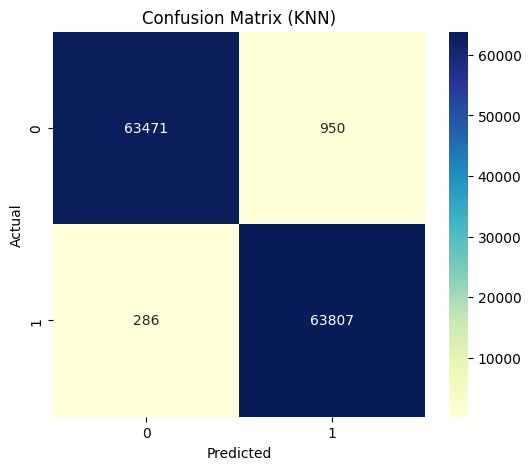

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (KNN)')
plt.show()
